In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve
from matplotlib.ticker import MultipleLocator


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

# 900 °C

In [2]:
file_path = r"../Data/Raman/900_front_voigt.txt"

data_900 = pd.read_csv(file_path, sep='\t')
print(data_900.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           934 non-null    float64
 1   Raman shift          934 non-null    float64
 2   Intensity            934 non-null    float64
 3   Baseline             934 non-null    float64
 4   Corrected Intensity  934 non-null    float64
 5   Curve 1              934 non-null    float64
 6   Curve 2              934 non-null    float64
 7   Curve 3              934 non-null    float64
 8   Curve 4              934 non-null    float64
 9   Curve 5              934 non-null    float64
 10  Fit Sum              934 non-null    float64
dtypes: float64(11)
memory usage: 80.4 KB
None


In [3]:
# file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\Raman\900_front.txt"

# data_900 = pd.read_csv(file_path, sep='\t')
# print(data_900.info())

In [4]:
# fig, ax = plt.subplots(figsize=(8, 6))

# ax.plot(data_900['Raman shift'], data_900['Corrected Intensity'], 'k.', alpha=0.3, label='Data')
# ax.plot(data_900['Raman shift'], data_900['Fit Sum'], color="#000080", label='Fit Sum')
# # fit interval: 1184	1749

# peaks = ['Curve 1', 'Curve 2', 'Curve 3', 'Curve 4', 'Curve 5']
# colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(peaks)))
# for index, peak in enumerate(peaks):
#     plt.fill_between(data_900['Raman shift'], data_900[peak], 0, color=colors[index], alpha=0.5, label=peak)

# # ----------------------------------------------------------------------------------------------------------------
# # px1 = data_900['Raman shift'][data_900['Curve 1'].idxmax()]
# # py1 = data_900['Curve 1'][data_900['Curve 1'].idxmax()]
# px1 = 1279.929
# py1 = np.interp(px1, data_900['Raman shift'], data_900['Curve 1'])
# plt.annotate(f'D4\n{px1:.1f}', xy=(px1, py1), 
#             xytext=(px1-50, py1 + 300), ha='center', va='bottom', 
#             arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

# px2 = 1352.832
# py2 = np.interp(px2, data_900['Raman shift'], data_900['Curve 2'])
# plt.annotate(f'D1\n{px2:.1f}', xy=(px2, py2), 
#             xytext=(px2-60, py2 + 250), ha='center', va='bottom', 
#             arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

# px3 = 1422.027
# py3 = np.interp(px3, data_900['Raman shift'], data_900['Curve 3'])
# plt.annotate(f'D3\n{px3:.1f}', xy=(px3, py3), 
#             xytext=(px3+55, py3 + 700), ha='center', va='bottom', 
#             arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

# px4 = 1585.219
# py4 = np.interp(px4, data_900['Raman shift'], data_900['Curve 4'])
# plt.annotate(f'G\n{px4:.1f}', xy=(px4, py4), 
#             xytext=(px4-40, py4 + 250), ha='center', va='bottom', 
#             arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

# px5 = 1680.581
# py5 = np.interp(px5, data_900['Raman shift'], data_900['Curve 5'])
# plt.annotate(f"D2\n{px5:.1f}", xy=(px5, py5), 
#             xytext=(px5+50, py5 + 250), ha='center', va='bottom', 
#             arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')
# # ----------------------------------------------------------------------------------------------------------------

# ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
# ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
# ax.set_yticklabels([])
# ax.set_xlim(1150, 1800)
# ax.set_ylim(-200, 4800)
# ax.xaxis.set_minor_locator(MultipleLocator(25))
# ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
# plt.tight_layout()
# # plt.savefig(f'../Images/Raman/900_front_fit.pdf', dpi=500)
# plt.show()

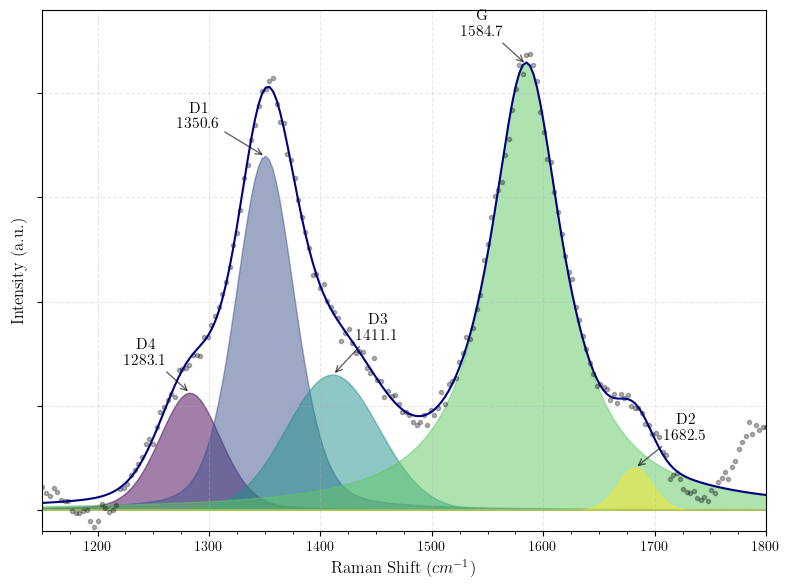

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_900['Raman shift'], data_900['Corrected Intensity'], 'k.', alpha=0.3, label='Data')
ax.plot(data_900['Raman shift'], data_900['Fit Sum'], color="#000080", label='Fit Sum')
# fit interval: 1184	1749

peaks = ['Curve 1', 'Curve 2', 'Curve 3', 'Curve 4', 'Curve 5']
colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(peaks)))
for index, peak in enumerate(peaks):
    plt.fill_between(data_900['Raman shift'], data_900[peak], 0, color=colors[index], alpha=0.5, label=peak)

# ----------------------------------------------------------------------------------------------------------------
# px1 = data_900['Raman shift'][data_900['Curve 1'].idxmax()]
# py1 = data_900['Curve 1'][data_900['Curve 1'].idxmax()]
px1 = 1283.075
py1 = np.interp(px1, data_900['Raman shift'], data_900['Curve 1'])
plt.annotate(f'D4\n{px1:.1f}', xy=(px1, py1), 
            xytext=(px1-40, py1 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px2 = 1350.567
py2 = np.interp(px2, data_900['Raman shift'], data_900['Curve 2'])
plt.annotate(f'D1\n{px2:.1f}', xy=(px2, py2), 
            xytext=(px2-60, py2 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px3 = 1411.133
py3 = np.interp(px3, data_900['Raman shift'], data_900['Curve 3'])
plt.annotate(f'D3\n{px3:.1f}', xy=(px3, py3), 
            xytext=(px3+40, py3 + 320), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px4 = 1584.708
py4 = np.interp(px4, data_900['Raman shift'], data_900['Curve 4'])
plt.annotate(f'G\n{px4:.1f}', xy=(px4, py4), 
            xytext=(px4-40, py4 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px5 = 1682.5198
py5 = np.interp(px5, data_900['Raman shift'], data_900['Curve 5'])
plt.annotate(f"D2\n{px5:.1f}", xy=(px5, py5), 
            xytext=(px5+45, py5 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')
# ----------------------------------------------------------------------------------------------------------------

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(1150, 1800)
ax.set_ylim(-200, 4800)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout()
# plt.savefig(f'../Images/Raman/900_front_fit.pdf', dpi=500)
plt.show()

$L_a = \frac{260}{E_L^4} \cdot \left(\frac{A_D}{A_G}\right)^{-1}$

In [6]:
from scipy.integrate import simpson
q = 1.602176634e-19         # Elementary charge (C)
h = 6.62607015e-34          # Planck constant (J*s)
c0 = 299792458              # speed of light (m/s)
laser = 532e-9

mask = (data_900['Raman shift'] >= 1180) & (data_900['Raman shift'] <= 1750)

A_D_900 = simpson(data_900['Curve 2'][mask], data_900['Raman shift'][mask])
A_G_900 = simpson(data_900['Curve 4'][mask], data_900['Raman shift'][mask])
print(A_D_900, A_G_900)

C_factor = 560/(((h*c0)/(laser*q))**4) 
L_900 = C_factor * (A_G_900/A_D_900)
print(C_factor, L_900)

# fig, ax = plt.subplots(figsize=(8, 6))
# ax.plot(data_900['Raman shift'][mask], data_900['Curve 2'][mask])
# ax.plot(data_900['Raman shift'][mask], data_900['Curve 4'][mask])
# fig.show()

246632.21287861333 477110.5831591073
18.983190311848475 36.72302532663901


In [7]:
# same using Intentity instead of area
I_D_900 = data_900['Curve 2'][mask].max()
I_G_900 = data_900['Curve 4'][mask].max()
print(I_D_900, I_G_900)

C_factor_I = 560/(((h*c0)/(laser*q))**4)
L_900_I = C_factor_I * (I_G_900/I_D_900)
print(C_factor_I, L_900_I)

3394.54092147763 4275.804381012632
18.983190311848475 23.911453766085685


# 800 °C 

In [8]:
file_path_800 = r"../Data/Raman/800_front_voigt.txt"

data_800 = pd.read_csv(file_path_800, sep='\t')
print(data_800.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           934 non-null    float64
 1   Raman shift          934 non-null    float64
 2   Intensity            934 non-null    float64
 3   Baseline             934 non-null    float64
 4   Corrected Intensity  934 non-null    float64
 5   Curve 1              934 non-null    float64
 6   Curve 2              934 non-null    float64
 7   Curve 3              934 non-null    float64
 8   Curve 4              934 non-null    float64
 9   Curve 5              934 non-null    float64
 10  Fit Sum              934 non-null    float64
dtypes: float64(11)
memory usage: 80.4 KB
None


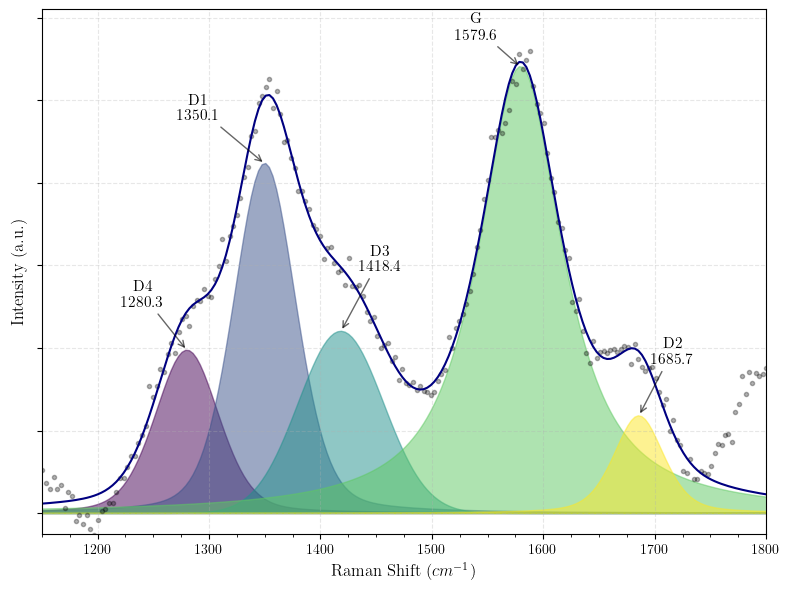

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_800['Raman shift'], data_800['Corrected Intensity'], 'k.', alpha=0.3, label='Data')
ax.plot(data_800['Raman shift'], data_800['Fit Sum'], color="#000080", label='Fit Sum')
# fit interval: 1184	1749

peaks = ['Curve 1', 'Curve 2', 'Curve 3', 'Curve 4', 'Curve 5']
colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(peaks)))
for index, peak in enumerate(peaks):
    plt.fill_between(data_800['Raman shift'], data_800[peak], 0, color=colors[index], alpha=0.5, label=peak)

# ----------------------------------------------------------------------------------------------------------------
# px1 = data_800['Raman shift'][data_800['Curve 1'].idxmax()]
px1 = 1280.258
py1 = np.interp(px1, data_800['Raman shift'], data_800['Curve 1'])
# py1 = data_800['Curve 1'][data_800['Curve 1'].idxmax()]
plt.annotate(f'D4\n{px1:.1f}', xy=(px1, py1), 
            xytext=(px1-40, py1 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px2 = 1350.0748
py2 = np.interp(px2, data_800['Raman shift'], data_800['Curve 2'])
plt.annotate(f'D1\n{px2:.1f}', xy=(px2, py2), 
            xytext=(px2-60, py2 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px3 = 1418.3994
py3 = np.interp(px3, data_800['Raman shift'], data_800['Curve 3'])
plt.annotate(f'D3\n{px3:.1f}', xy=(px3, py3), 
            xytext=(px3+35, py3 + 350), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px4 = 1579.6097
py4 = np.interp(px4, data_800['Raman shift'], data_800['Curve 4'])
plt.annotate(f'G\n{px4:.1f}', xy=(px4, py4), 
            xytext=(px4-40, py4 + 150), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px5 = 1685.73
py5 = np.interp(px5, data_800['Raman shift'], data_800['Curve 5'])
plt.annotate(f"D2\n{px5:.1f}", xy=(px5, py5), 
            xytext=(px5+30, py5 + 300), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')
# ----------------------------------------------------------------------------------------------------------------

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(1150, 1800)
ax.set_ylim(-125, 3050)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout()
# plt.savefig(f'../Images/Raman/800_front_fit.pdf', dpi=500)
plt.show()

In [10]:
mask = (data_800['Raman shift'] >= 1180) & (data_800['Raman shift'] <= 1750)

A_D_800 = simpson(data_800['Curve 2'][mask], data_800['Raman shift'][mask])
A_G_800 = simpson(data_800['Curve 4'][mask], data_800['Raman shift'][mask])
print(A_D_800, A_G_800)

# fig, ax = plt.subplots(figsize=(8, 6))
# ax.plot(data_800['Raman shift'][mask], data_800['Curve 2'][mask])
# ax.plot(data_800['Raman shift'][mask], data_800['Curve 4'][mask])
# fig.show()

C_factor = 560/(((h*c0)/(laser*q))**4)
L_800 = C_factor * (A_G_800/A_D_800)
print(C_factor, L_800)

163609.58675760022 331912.9648650587
18.983190311848475 38.51098889662463


In [16]:
# same using Intentity instead of area
I_D_800 = data_800['Curve 2'][mask].max()
I_G_800 = data_800['Curve 4'][mask].max()

C_factor_I = 560/(((h*c0)/(laser*q))**4)
L_800_I = C_factor_I * (I_G_800/I_D_800)
print(C_factor_I, L_800_I)

print(f"Crystallite size from area ratio: L_800 = {L_800:.2f} nm, L_900 = {L_900:.2f} nm")
print(f"Crystallite size from intensity ratio: L_800_I = {L_800_I:.2f} nm, L_900_I = {L_900_I:.2f} nm")

18.983190311848475 24.23592825225064
Crystallite size from area ratio: L_800 = 38.51 nm, L_900 = 36.72 nm
Crystallite size from intensity ratio: L_800_I = 24.24 nm, L_900_I = 23.91 nm


In [12]:
(L_900+L_800)/2

np.float64(37.61700711163182)

# Combined plot carbon

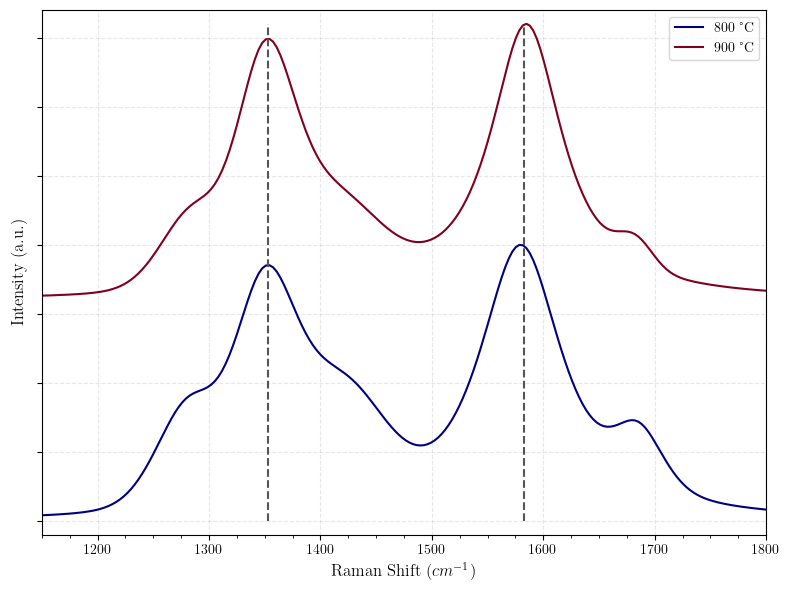

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

norm_800 = data_800['Fit Sum'] / data_800['Fit Sum'].max()
norm_900 = data_900['Fit Sum'] / data_900['Fit Sum'].max()
# norm_800 = data_800['Corrected Intensity'] / data_800['Corrected Intensity'].max()
# norm_900 = data_900['Corrected Intensity'] / data_900['Corrected Intensity'].max()

ax.plot(data_800['Raman shift'], norm_800, color="#000080", label='800 °C')
ax.plot(data_900['Raman shift'], norm_900 + 0.8, color="#800020", label='900 °C')

ax.vlines([1352.5, 1583], ymin=0, ymax=1.8, color="#555555", linestyle='--')

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(1150, 1800)
ax.set_ylim(-0.05, 1.85)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend()
plt.tight_layout()
# plt.savefig(f'../Images/Raman/800_front_fit.pdf', dpi=500)
plt.show()

# Combined plot nickel silicides

96.3546 $Ni_2Si$
137.8 $Ni_2Si$
181 $Ni_2Si$
212 $NiSi$
363 $NiSi$


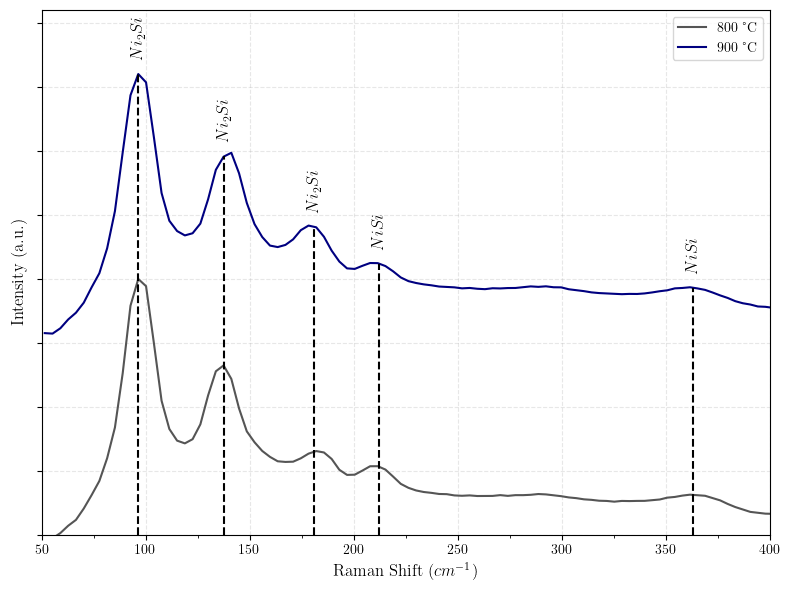

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

data_800["norm_800"] = data_800['Corrected Intensity'] / data_800['Corrected Intensity'].max()
data_900["norm_900"] = data_900['Corrected Intensity'] / data_900['Corrected Intensity'].max()

offset = 0.8
ax.plot(data_800['Raman shift'], data_800["norm_800"], color="#555555", label='800 °C')
ax.plot(data_900['Raman shift'], data_900["norm_900"] + offset, color="#000080", label='900 °C')

# ax.vlines([1352.5, 1583], ymin=0, ymax=1.8, color="#555555", linestyle='--')
peak_labels = {96.3546: '$Ni_2Si$', 137.8: '$Ni_2Si$', 181: '$Ni_2Si$', 212: '$NiSi$', 363: '$NiSi$'}

for position, name in peak_labels.items():
    print(position, name)
    y_height = np.interp(position, data_900['Raman shift'], data_900['norm_900'])
    ax.vlines([position], ymin=0, ymax=y_height + offset, color="#000000", linestyle='--')
    plt.text(position, y_height +offset+ 0.05, name, 
            ha='center', va='bottom', fontsize=12, fontweight='bold', rotation=90)
    

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(50, 400)
ax.set_ylim(0, 2.05)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend()
plt.tight_layout()
# plt.savefig(f'../Images/Raman/NiSi_Raman.pdf', dpi=500)
plt.show()

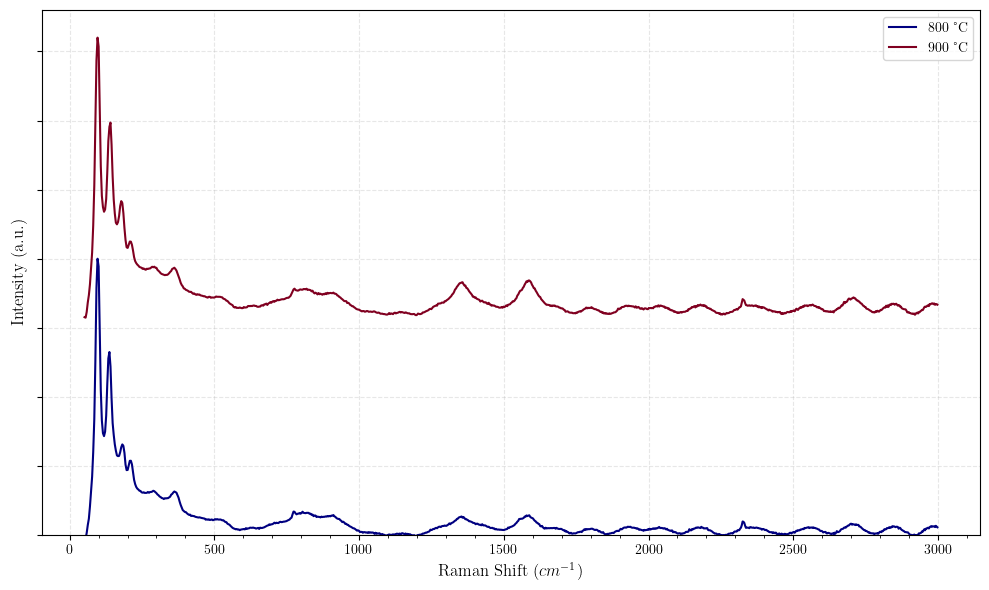

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

data_800["norm_800"] = data_800['Corrected Intensity'] / data_800['Corrected Intensity'].max()
data_900["norm_900"] = data_900['Corrected Intensity'] / data_900['Corrected Intensity'].max()

offset = 0.8
ax.plot(data_800['Raman shift'], data_800["norm_800"], color="#000080", label='800 °C')
ax.plot(data_900['Raman shift'], data_900["norm_900"] + offset, color="#800020", label='900 °C')

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
# ax.set_xlim(50, 400)
ax.set_ylim(0, 1.9)
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend()
plt.tight_layout()
# plt.savefig(f'../Images/Raman/NiSi.pdf', dpi=500)
plt.show()